Important Functions:

In [74]:
import numpy as np                   #importing numpy package for scientific computing
import matplotlib.pyplot as plt      #importing matplotlib package for plots
from scipy.signal import welch
import matplotlib
from matplotlib import animation
import pandas as pd


def load_data(filepath):
    # Load all data from the file, skipping the 7-line header
    raw = np.genfromtxt(filepath, delimiter=";", skip_header=7)

    time = raw[:, 0]
    EMF1 = raw[:, 1]
    EMF2 = raw[:, 2]
    EMF3 = raw[:, 3]
    EMF4 = raw[:, 4]
    EMF5 = raw[:, 5]

    # Remove the mean of the first 60 seconds (still water baseline)
    # This way any mean current in the signal is preserved
    still_water_mask = time < 60
    EMF1 -= np.mean(EMF1[still_water_mask])
    EMF2 -= np.mean(EMF2[still_water_mask])
    EMF3 -= np.mean(EMF3[still_water_mask])
    EMF4 -= np.mean(EMF4[still_water_mask])
    EMF5 -= np.mean(EMF5[still_water_mask])

    # Now trim the first and last 60 seconds
    mask = (time >= 200) & (time <= time[-1] - 200)
    time = time[mask]
    EMF1, EMF2, EMF3, EMF4, EMF5 = EMF1[mask], EMF2[mask], EMF3[mask], EMF4[mask], EMF5[mask]
    EMF1, EMF2, EMF3, EMF4, EMF5 = EMF1 * 0.1023, EMF2 * 0.1023, EMF3 * 0.1023, EMF4 * 0.1023, EMF5 * 0.1023
    return time, EMF1, EMF2, EMF3, EMF4, EMF5

def plot_time_series(time, EMF1, EMF2, EMF3, EMF4, EMF5):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    for i, (ax, EMF) in enumerate(zip(axes, [EMF1, EMF2, EMF3, EMF4, EMF5]), start=1):
        ax.plot(time, EMF, label=f'EMF{i}')
        ax.set_ylabel('Velocity (m/s)')
        ax.set_title(f'EMF{i}')
        ax.legend(loc='upper right')
        ax.grid()

    axes[-1].set_xlabel('Time (s)')
    plt.suptitle('Time Series at all EMF locations')
    plt.tight_layout()
    plt.show()

def plot_time_series_limited(time, EMF1, EMF2, EMF3, EMF4, EMF5):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    for i, (ax, EMF) in enumerate(zip(axes, [EMF1, EMF2, EMF3, EMF4, EMF5]), start=1):
        ax.plot(time, EMF, label=f'EMF{i}')
        ax.set_ylabel('Velocity (m/s)')
        ax.set_title(f'EMF{i}')
        ax.legend(loc='upper right')
        ax.grid()

    axes[-1].set_xlabel('Time (s)')
    axes[-1].set_xlim(400, 420)
    plt.suptitle('Time Series at all EMF locations')
    plt.tight_layout()
    plt.show()

def read_grid(name_table, nx):
    grp = np.loadtxt(name_table, skiprows=0)
    ns, no = grp.shape
    nt = round(ns/nx)
    A = np.reshape(grp, (nx, nt, no), order="F")
    x    =  A[:, 0, 1]
    zbed = -A[:, 0, 3]

    # Shift zbed so the flat bottom starts at 0
    zbed = zbed - zbed.min()

    # Water depth at each EMF location (1-6)


    return x, zbed

def plot_flume(x, zbed, setup):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]

    water_levels  = {1: 0.510, 2: 0.509, 3: 0.508, 4: 0.507, 5: 0.506, 6: 0.505}
    water_level = water_levels[setup]

    plt.figure(figsize=(14, 4))
    plt.plot(x, zbed, color='black', label='Bed profile')
    plt.fill_between(x, zbed, 0, color='sandybrown', alpha=0.5)
    plt.axhline(y=water_level, color='blue', alpha=0.3, label=f'Water surface (h={water_level}m)')



    for i, pos in enumerate(emf_positions):
        plt.axvline(x=pos, linestyle='--', label=f'EMF{i+1} ({pos}m)')

    plt.xlabel('x (m)')
    plt.ylabel('Elevation (m)')
    plt.title('Flume bed profile with EMF sensor locations')
    plt.legend(loc='upper left')
    plt.grid()
    plt.show()

def plot_sediment_transport(time, EMF1, EMF2, EMF3, EMF4, EMF5, Fs):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]  # only 5 sensors
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5]  # only 5 sensors

    # --- Compute all terms at each EMF location ---
    u3            = []
    u3_ss         = []
    three_u2ss_u  = []
    three_u2ss_uig= []
    sed_total     = []

    for EMF in emf_data:
        u_mean      = np.mean(EMF)
        u_demeaned  = EMF - u_mean

        # Sea-swell band (0.05 - 1.0 Hz)
        u_ss        = frequency_filter(u_demeaned, Fs, f_low=0.05, f_high=1.0)

        # Infragravity band (0.005 - 0.05 Hz)
        u_ig        = frequency_filter(u_demeaned, Fs, f_low=0.005, f_high=0.05)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    # --- Plot as points at the 5 EMF locations ---
    plt.figure(figsize=(12, 4))
    plt.plot(emf_positions, u3,             label='Mean current',             color='red',    marker='o', markersize=4)
    plt.plot(emf_positions, u3_ss,          label='Skewness',                 color='blue',   marker='o', markersize=4)
    plt.plot(emf_positions, three_u2ss_u,   label='Stirring term',            color='green',  marker='o', markersize=4)
    plt.plot(emf_positions, three_u2ss_uig, label='Infragravity term',        color='purple', marker='o', markersize=4)
    plt.plot(emf_positions, sed_total,      label='Total sediment transport', color='black',  marker='o', markersize=4)

    plt.xlabel('x (m)')
    plt.ylabel('Sediment transport proxy (m³/s³)')
    plt.legend()
    plt.grid()
    plt.show()

def frequency_filter(data, Fs, f_low, f_high):
    ''' frequency_filter is a simple spectral filter in which the unwanted frequencies (below f_low and above f_high) 
        are set to zero before coming back to the time-domain
            input: data timeseries you want to filter
                   F_s the sampling frequency of this timeseries (Hz)
                   f_low and f_high are the limits of the band pass filter (Hz)
            output: data_filtered band pass filtered timeseries (same unit as the input timeseries)
    '''
    
    N = len(data)

    fft_data = np.fft.fft(data)  # fourier transform of the signal

    freq_vector = np.fft.fftfreq(N, d=1/Fs) # corresponding (2-sided) frequency axis (includes positive and negative values)
    
    idx = np.where((abs(freq_vector) > f_high) | (abs(freq_vector) <= f_low)) # we select the indices to filter out
    
    fft_data[idx]=0.  # we set the the fourier coefficients corresponding to abs(f)>f_high and abs(f)<f_low to zero

    data_filtered = np.fft.ifft(fft_data).real  # we come back to the time domain with an inverse Fourier transform
    
    return data_filtered

Grid Plot for Setup 1:

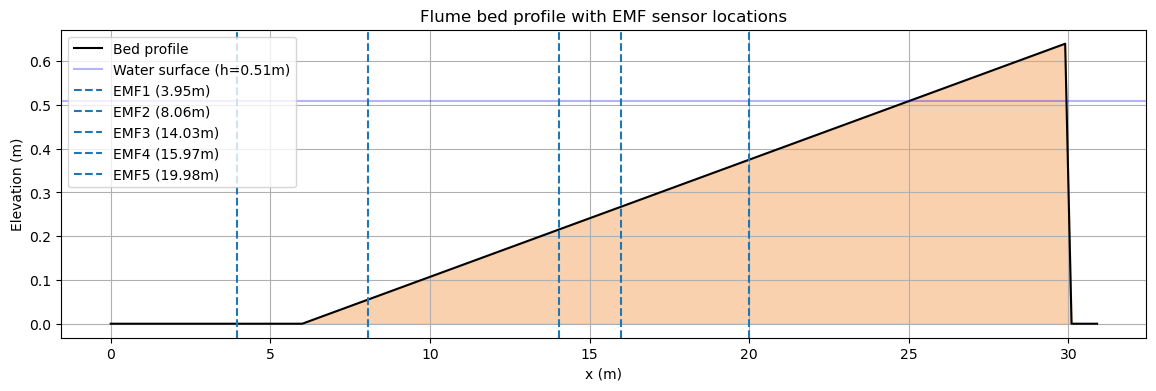

In [75]:
x, zbed = read_grid("grid_output.tbl", 310)
plot_flume(x, zbed, 1)

Plot Raw Velocity profiles at different sensor locations:

In [76]:
time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03 = load_data('Set1/EMF_test1.ASC')

Swash Simulations Functions:

In [77]:
def read_point_output(name_table):
    '''reads the wave gauge output type 
            input: name_table is the name of the output table (e.g. name_table="gauge1.tbl" in the original SWASH input file)
            outputs:
                t: vector containing the time in s
                eta: vector containing the surface elevation in m
                ux: vector containing the depth averaged horizontal velocity in m/s
    '''
    
    gauge = np.loadtxt(name_table,skiprows=7)

    t   = gauge[:,0] #time vector (s)
    ux  = gauge[:,2] #depth-averaged velocity in the x-direction (m/s)
    #uy = gauge[:,3] #depth-averaged velocity in the y-direction (0 at all time because we are looking at a 1D case)
    Eta = gauge[:,1] #surface elevation (m)
    return t, Eta, ux #, uy

def calculate_sediment_transport(time, EMF1, EMF2, EMF3, EMF4, EMF5, Fs):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5]

    u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total = [], [], [], [], []

    for EMF in emf_data:
        u_mean  = np.mean(EMF)
        u_dem   = EMF - u_mean
        u_ss    = frequency_filter(u_dem, Fs, f_low=0.25,  f_high=10.0)
        u_ig    = frequency_filter(u_dem, Fs, f_low=0.005, f_high=0.25)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    return emf_positions, u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total


Get the Data from Simulations:

In [78]:
time1_swash, Eta1_1, ux1_1 = read_point_output('Set1Swash/gauge1.tbl')
time1_swash, Eta1_2, ux1_2 = read_point_output('Set1Swash/gauge2.tbl')
time1_swash, Eta1_3, ux1_3 = read_point_output('Set1Swash/gauge3.tbl')
time1_swash, Eta1_4, ux1_4 = read_point_output('Set1Swash/gauge4.tbl')
time1_swash, Eta1_5, ux1_5 = read_point_output('Set1Swash/gauge5.tbl')
time1_swash, Eta1_6, ux1_6 = read_point_output('Set1Swash/gauge6.tbl')

time2_swash, Eta2_1, ux2_1 = read_point_output('Set2Swash/gauge1.tbl')
time2_swash, Eta2_2, ux2_2 = read_point_output('Set2Swash/gauge2.tbl')
time2_swash, Eta2_3, ux2_3 = read_point_output('Set2Swash/gauge3.tbl')
time2_swash, Eta2_4, ux2_4 = read_point_output('Set2Swash/gauge4.tbl')
time2_swash, Eta2_5, ux2_5 = read_point_output('Set2Swash/gauge5.tbl')
time2_swash, Eta2_6, ux2_6 = read_point_output('Set2Swash/gauge6.tbl')

time3_swash, Eta3_1, ux3_1 = read_point_output('Set3Swash/gauge1.tbl')
time3_swash, Eta3_2, ux3_2 = read_point_output('Set3Swash/gauge2.tbl')
time3_swash, Eta3_3, ux3_3 = read_point_output('Set3Swash/gauge3.tbl')
time3_swash, Eta3_4, ux3_4 = read_point_output('Set3Swash/gauge4.tbl')
time3_swash, Eta3_5, ux3_5 = read_point_output('Set3Swash/gauge5.tbl')
time3_swash, Eta3_6, ux3_6 = read_point_output('Set3Swash/gauge6.tbl')

time4_swash, Eta4_1, ux4_1 = read_point_output('Set4Swash/gauge1.tbl')
time4_swash, Eta4_2, ux4_2 = read_point_output('Set4Swash/gauge2.tbl')
time4_swash, Eta4_3, ux4_3 = read_point_output('Set4Swash/gauge3.tbl')
time4_swash, Eta4_4, ux4_4 = read_point_output('Set4Swash/gauge4.tbl')
time4_swash, Eta4_5, ux4_5 = read_point_output('Set4Swash/gauge5.tbl')
time4_swash, Eta4_6, ux4_6 = read_point_output('Set4Swash/gauge6.tbl')

time5_swash, Eta5_1, ux5_1 = read_point_output('Set5Swash/gauge1.tbl')
time5_swash, Eta5_2, ux5_2 = read_point_output('Set5Swash/gauge2.tbl')
time5_swash, Eta5_3, ux5_3 = read_point_output('Set5Swash/gauge3.tbl')
time5_swash, Eta5_4, ux5_4 = read_point_output('Set5Swash/gauge4.tbl')
time5_swash, Eta5_5, ux5_5 = read_point_output('Set5Swash/gauge5.tbl')
time5_swash, Eta5_6, ux5_6 = read_point_output('Set5Swash/gauge6.tbl')

time6_swash, Eta6_1, ux6_1 = read_point_output('Set6Swash/gauge1.tbl')
time6_swash, Eta6_2, ux6_2 = read_point_output('Set6Swash/gauge2.tbl')
time6_swash, Eta6_3, ux6_3 = read_point_output('Set6Swash/gauge3.tbl')
time6_swash, Eta6_4, ux6_4 = read_point_output('Set6Swash/gauge4.tbl')
time6_swash, Eta6_5, ux6_5 = read_point_output('Set6Swash/gauge5.tbl')
time6_swash, Eta6_6, ux6_6 = read_point_output('Set6Swash/gauge6.tbl')

time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06 = load_data('Set2/EMF_test2.ASC')
time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09 = load_data('Set3/EMF_test3.ASC')
time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12 = load_data('Set4/EMF_test4.ASC')
time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15 = load_data('Set5/EMF_test5.ASC')
time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18 = load_data('Set6/EMF_test6.ASC')

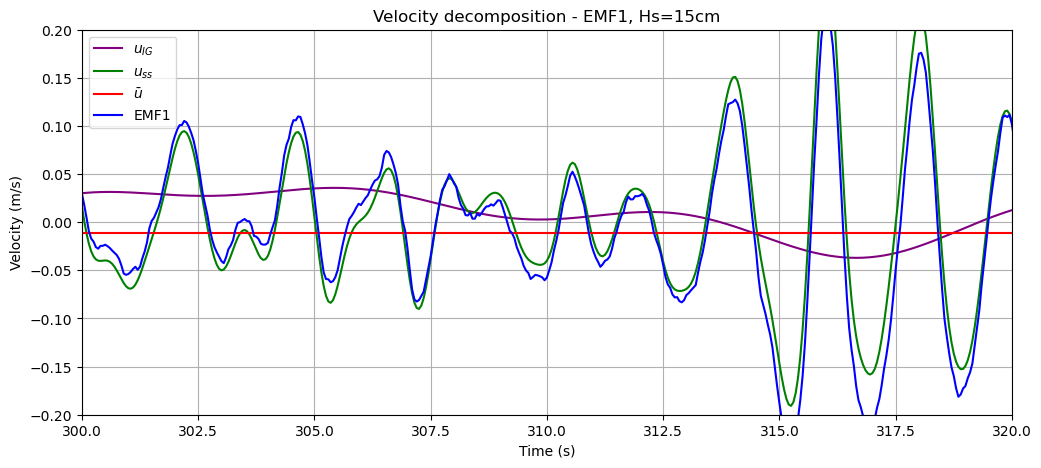

Case     x (m)      MAE (m/s)       Max Error (m/s)
--------------------------------------------------
3cm      3.95       0.001715        0.027198       
3cm      22.01      0.005685        0.057466       

9cm      3.95       0.002289        0.077430       
9cm      22.01      0.019819        0.120203       

18cm     3.95       0.005482        0.068839       
18cm     22.01      0.021430        0.146085       



In [79]:
#plot decomposed signal
u_mean = np.mean(EMF1_15)
u_dem  = EMF1_15 - u_mean
u_ss   = frequency_filter(EMF1_15, Fs=20, f_low=0.15,  f_high=1.7)
u_ig_dem = frequency_filter(EMF1_15, Fs=20, f_low=0.005, f_high=0.15)
u_mean_array = np.full(len(time5), u_mean)

plt.figure(figsize=(12, 5))
plt.plot(time5, u_ig_dem,    color='purple', label='$u_{IG}$')
plt.plot(time5, u_ss,        color='green',  label='$u_{ss}$')
plt.plot(time5, u_mean_array,color='red',    label='$\\bar{u}$')
plt.plot(time5, EMF1_15,     color='blue',   label='EMF1')
plt.xlim(300, 320)
plt.ylim(-0.2, 0.2)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity decomposition - EMF1, Hs=15cm')
plt.legend()
plt.grid()
plt.show()

print(f"{'Case':<8} {'x (m)':<10} {'MAE (m/s)':<15} {'Max Error (m/s)':<15}")
print(f"{'-'*50}")

emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]

cases_sel = {
    '3cm':  (time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03),
    '9cm':  (time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09),
    '18cm': (time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18),
}

for label, (time_, *emfs) in cases_sel.items():
    for emf, pos in zip([emfs[0], emfs[-1]], [emf_positions[0], emf_positions[-1]]):
        u_mean       = np.mean(emf)
        u_ss         = frequency_filter(emf, Fs=20, f_low=0.25,  f_high=1.7)
        u_ig         = frequency_filter(emf, Fs=20, f_low=0.005, f_high=0.25)
        u_mean_array = np.full(len(emf), u_mean)
        u_calc       = u_ss + u_ig + u_mean_array
        error        = u_calc - emf
        mae          = np.mean(np.abs(error))
        max_err      = np.max(np.abs(error))
        print(f"{label:<8} {pos:<10.2f} {mae:<15.6f} {max_err:<15.6f}")
    print()

Plot Simulation against Experiment 3cm:

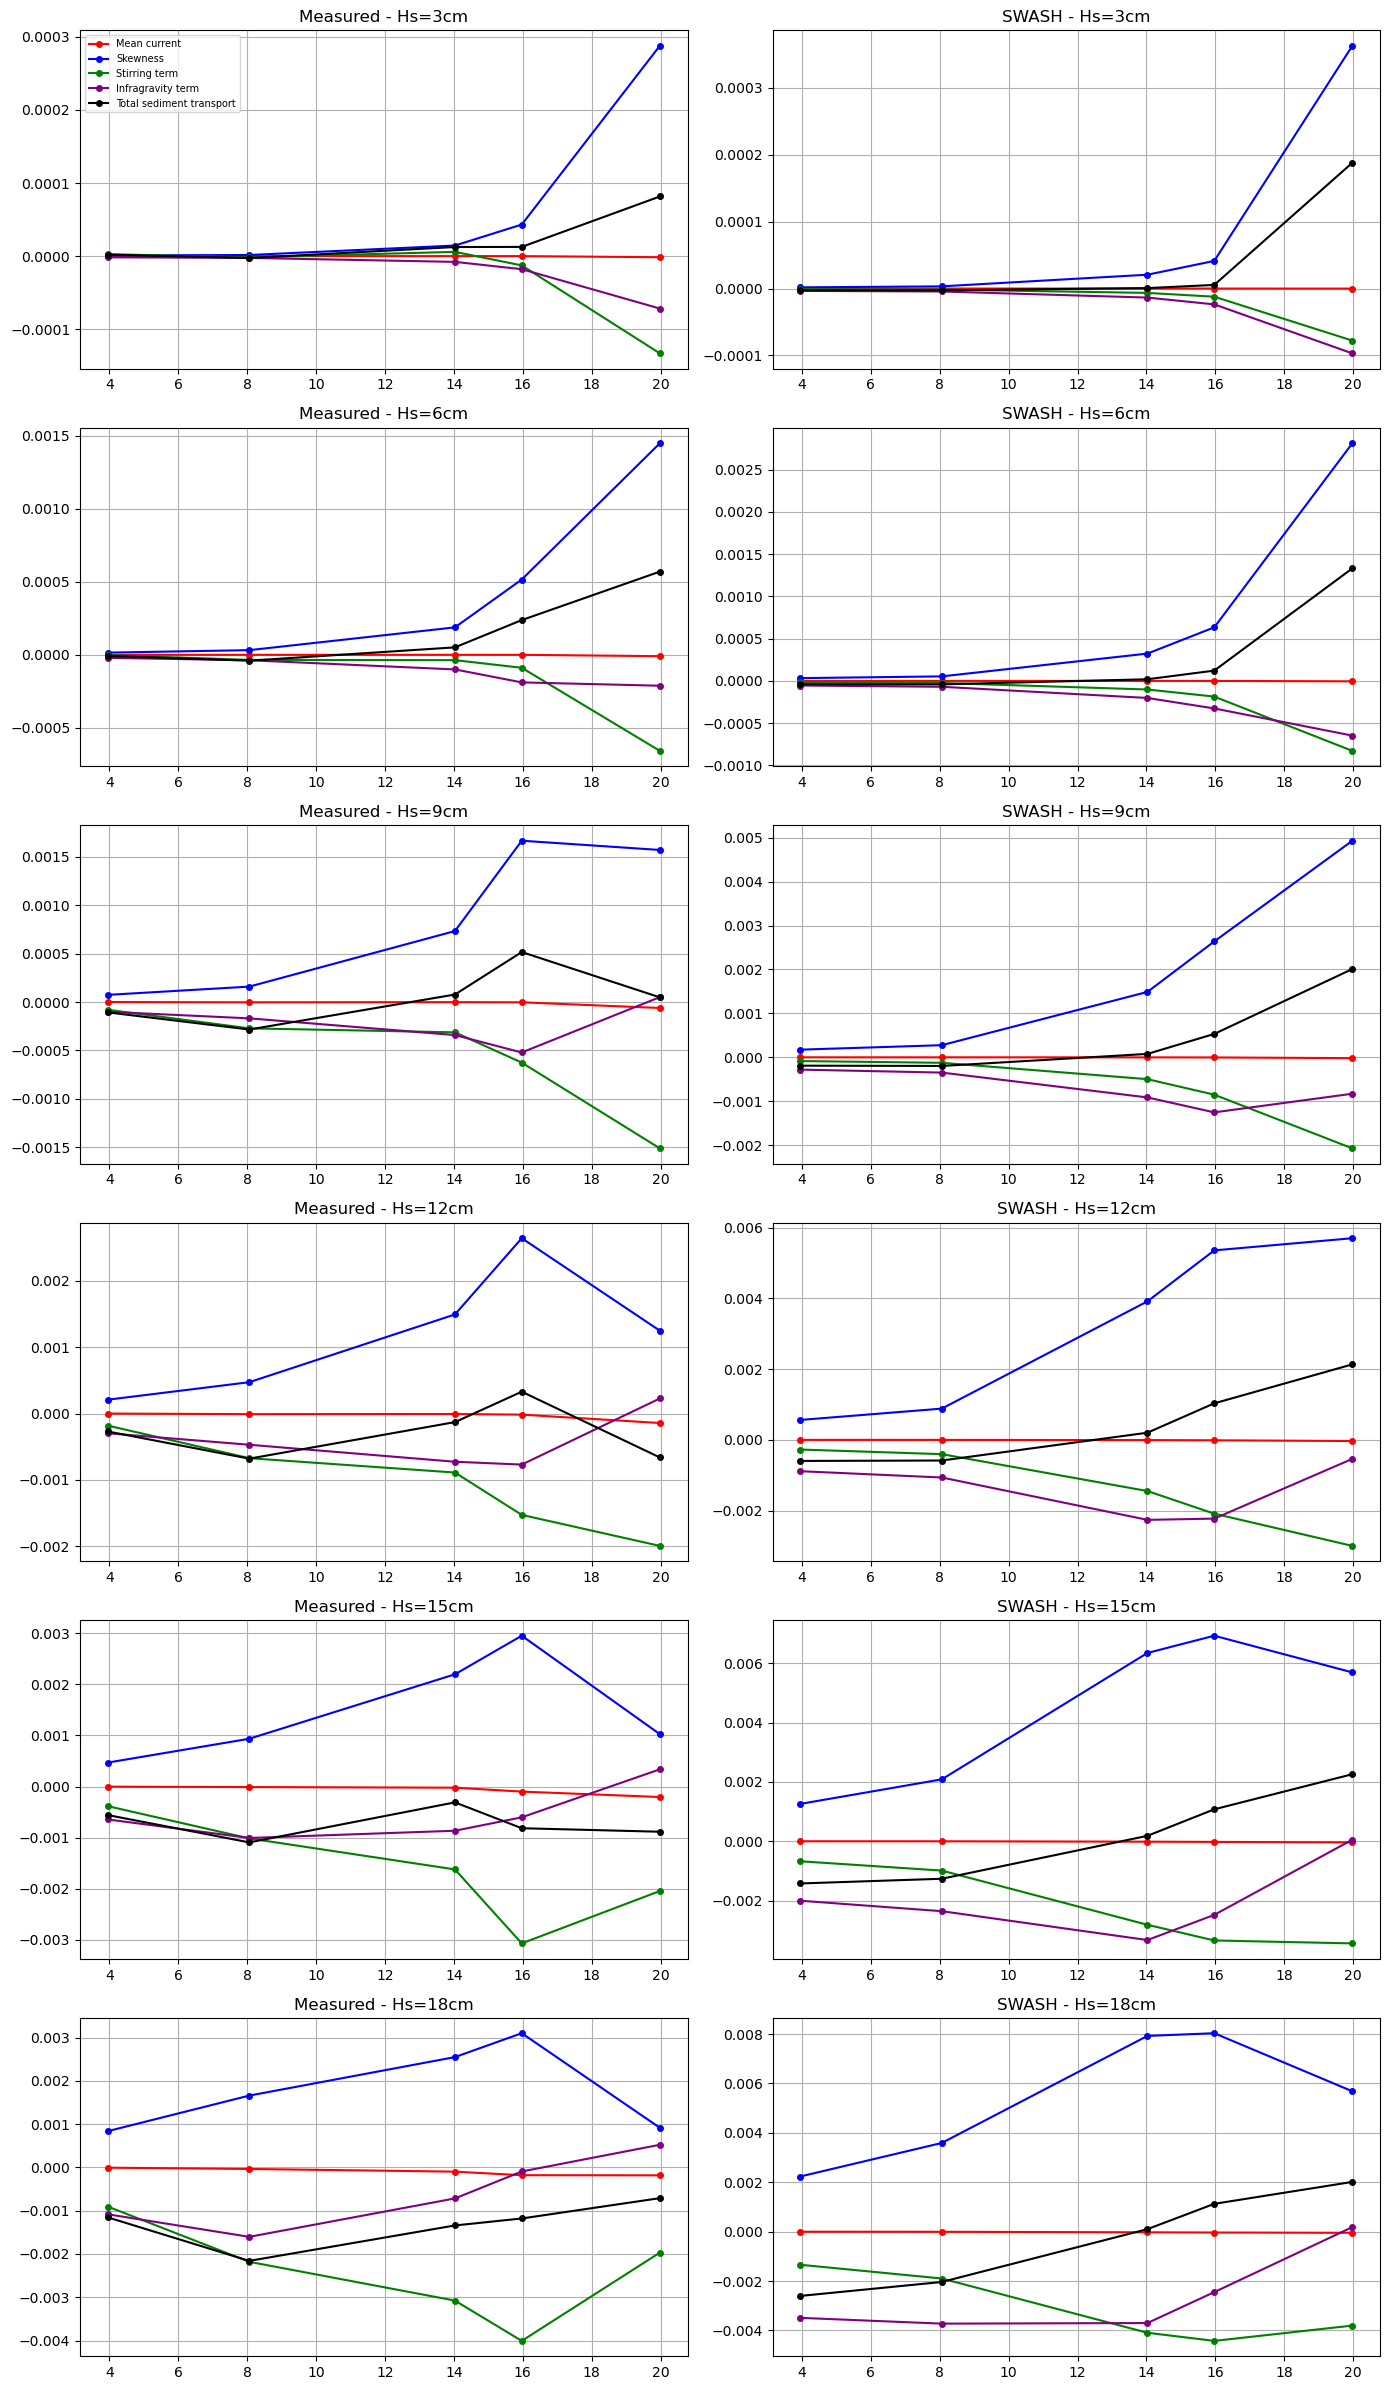

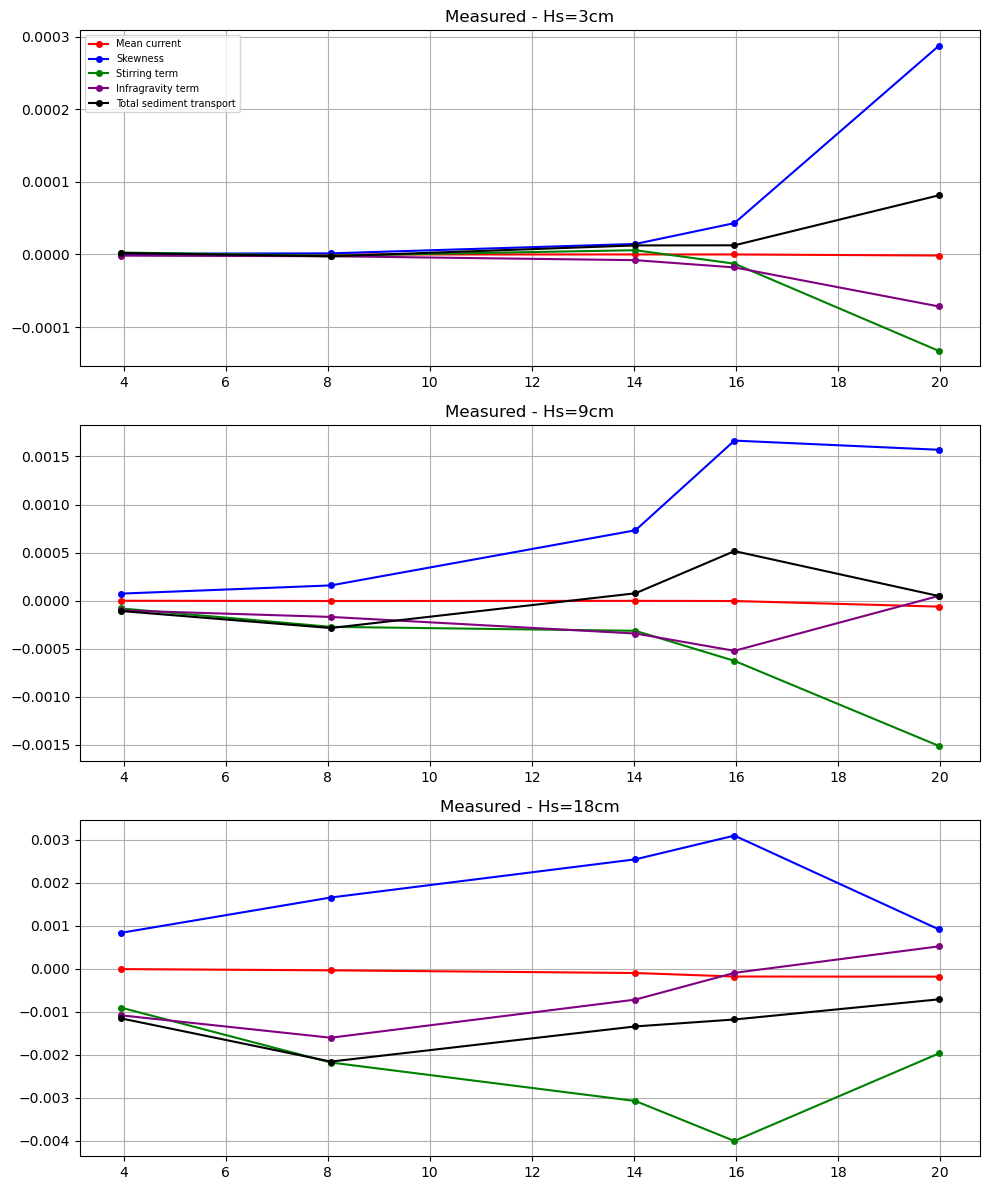

In [80]:
fig, axes = plt.subplots(6, 2, figsize=(14, 24))

datasets = [
    (time1,       EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, time1_swash, ux1_1, ux1_2, ux1_3, ux1_4, ux1_5, '3cm'),
    (time2,       EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, time2_swash, ux2_1, ux2_2, ux2_3, ux2_4, ux2_5, '6cm'),
    (time3,       EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, time3_swash, ux3_1, ux3_2, ux3_3, ux3_4, ux3_5, '9cm'),
    (time4,       EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, time4_swash, ux4_1, ux4_2, ux4_3, ux4_4, ux4_5, '12cm'),
    (time5,       EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, time5_swash, ux5_1, ux5_2, ux5_3, ux5_4, ux5_5, '15cm'),
    (time6,       EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, time6_swash, ux6_1, ux6_2, ux6_3, ux6_4, ux6_5, '18cm'),
]

plot_kwargs = [
    {'label': 'Mean current',             'color': 'red',    'marker': 'o', 'markersize': 4},
    {'label': 'Skewness',                 'color': 'blue',   'marker': 'o', 'markersize': 4},
    {'label': 'Stirring term',            'color': 'green',  'marker': 'o', 'markersize': 4},
    {'label': 'Infragravity term',        'color': 'purple', 'marker': 'o', 'markersize': 4},
    {'label': 'Total sediment transport', 'color': 'black',  'marker': 'o', 'markersize': 4},
]

for i, (time_m, e1, e2, e3, e4, e5, time_s, u1, u2, u3, u4, u5, hs) in enumerate(datasets):
    pos_m, u3_m, u3_ss_m, stir_m, ig_m, tot_m = calculate_sediment_transport(time_m, e1, e2, e3, e4, e5, Fs=20)
    pos_s, u3_s, u3_ss_s, stir_s, ig_s, tot_s = calculate_sediment_transport(time_s, u1, u2, u3, u4, u5, Fs=20)

    for values, ax, pos in [(  [u3_m, u3_ss_m, stir_m, ig_m, tot_m], axes[i, 0], pos_m),
                             (  [u3_s, u3_ss_s, stir_s, ig_s, tot_s], axes[i, 1], pos_s)]:
        for vals, kwargs in zip(values, plot_kwargs):
            ax.plot(pos, vals, **kwargs)
        ax.grid()

    axes[i, 0].set_title(f'Measured - Hs={hs}')
    axes[i, 1].set_title(f'SWASH - Hs={hs}')

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

datasets_filtered = [
    (time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, '3cm'),
    (time4, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, '9cm'),
    (time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, '18cm'),
]

for ax, (time_m, e1, e2, e3, e4, e5, hs) in zip(axes, datasets_filtered):
    pos_m, u3_m, u3_ss_m, stir_m, ig_m, tot_m = calculate_sediment_transport(time_m, e1, e2, e3, e4, e5, Fs=20)
    for vals, kwargs in zip([u3_m, u3_ss_m, stir_m, ig_m, tot_m], plot_kwargs):
        ax.plot(pos_m, vals, **kwargs)
    ax.set_title(f'Measured - Hs={hs}')
    ax.grid()

axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

Compute the Wave Spectrum

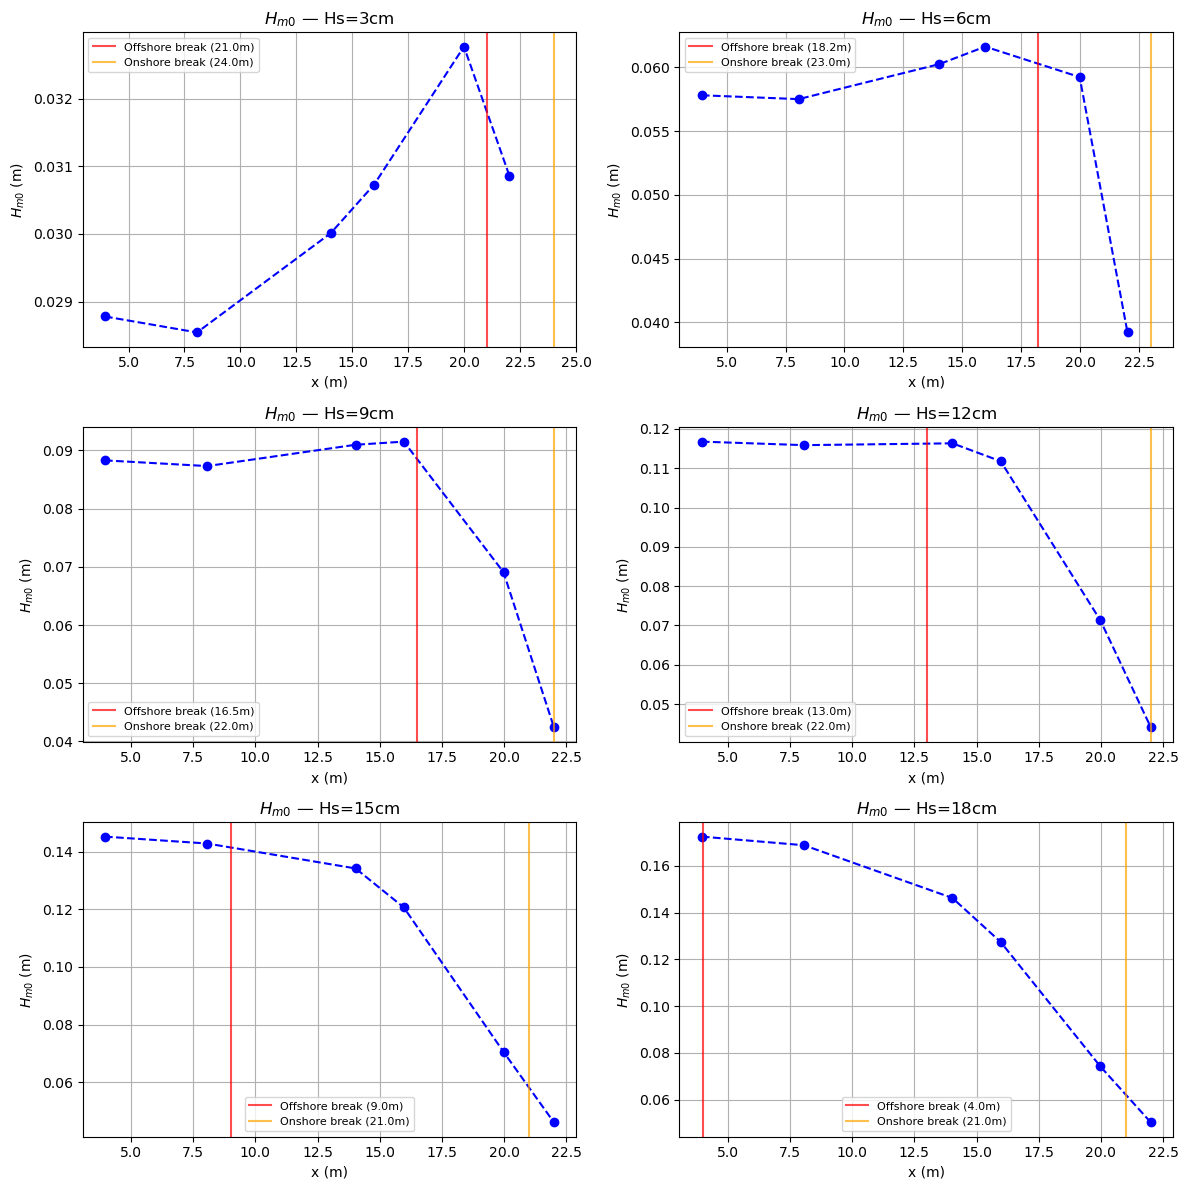

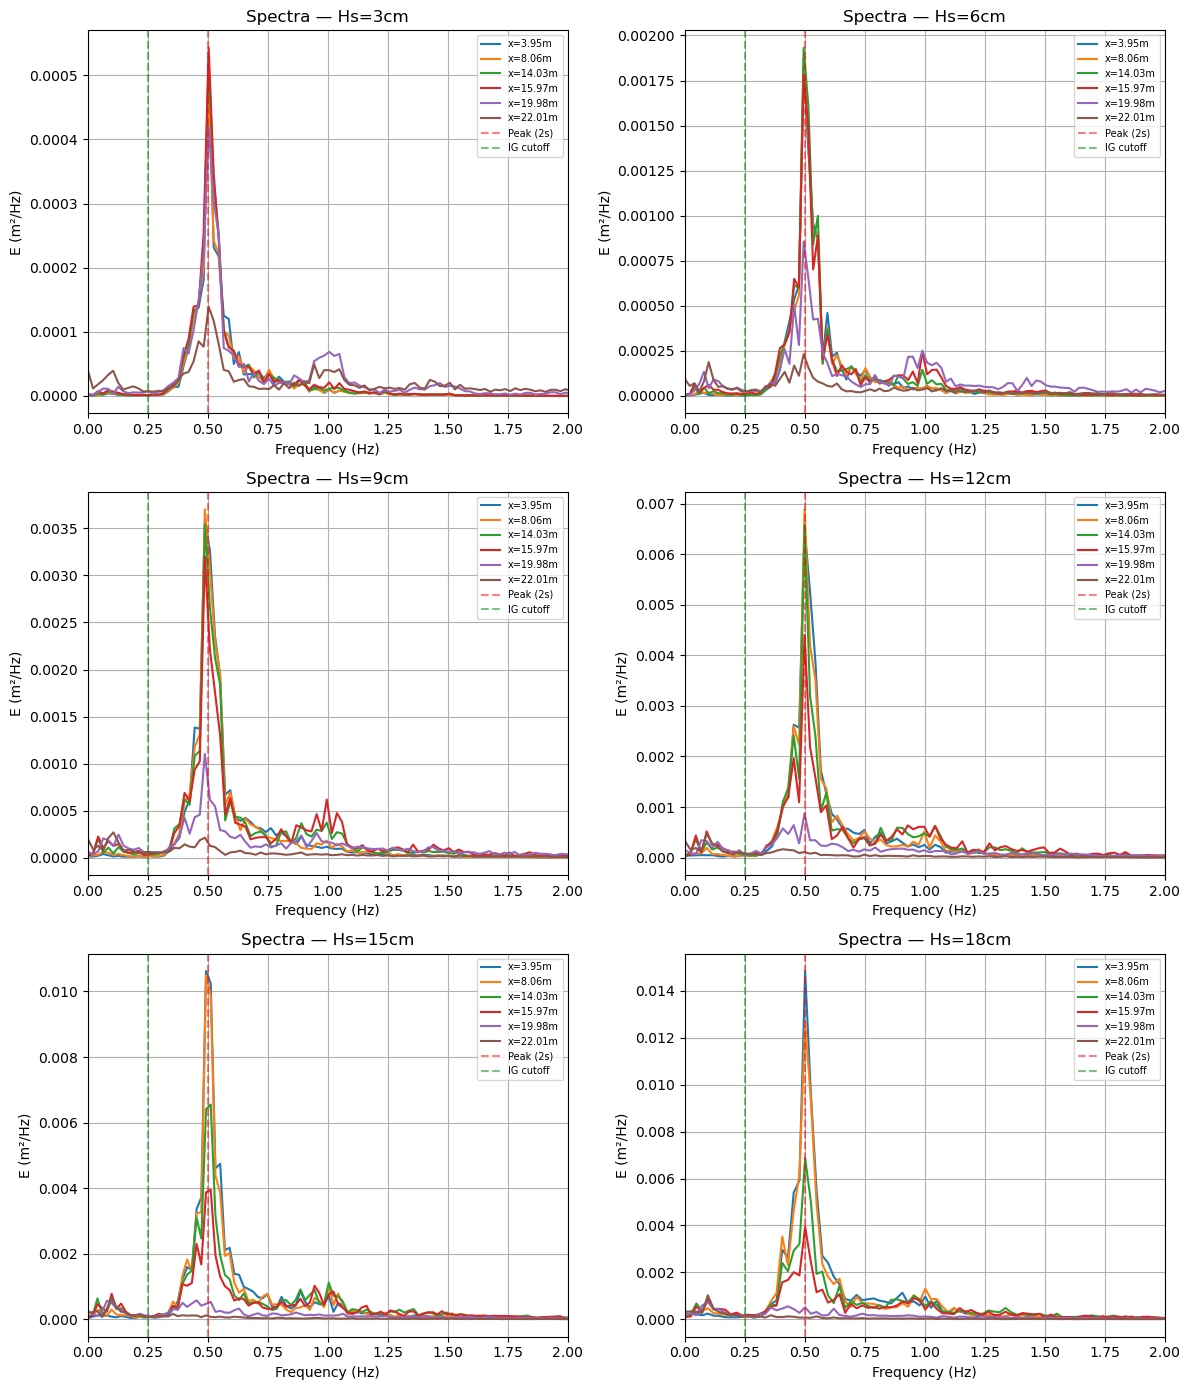

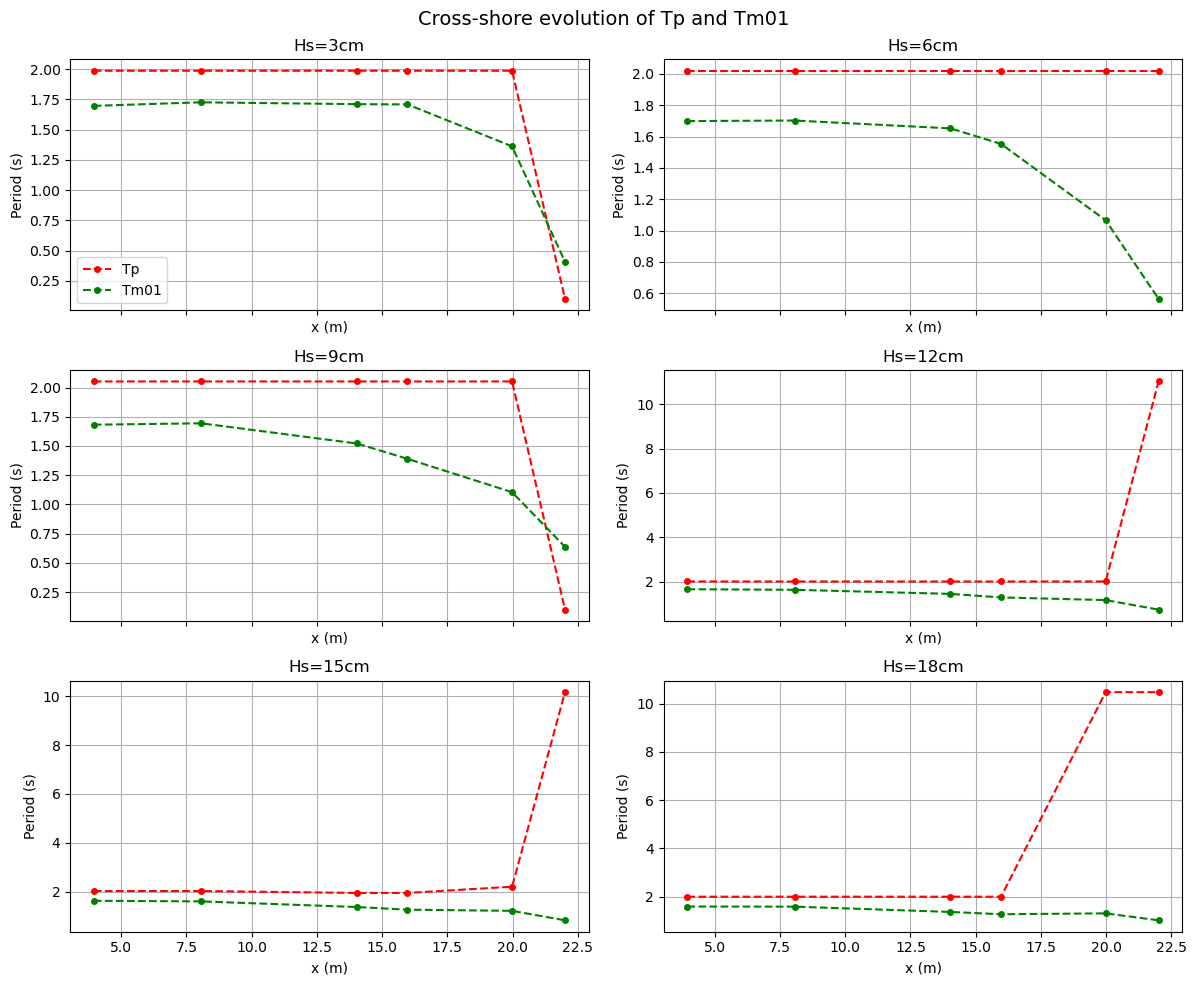

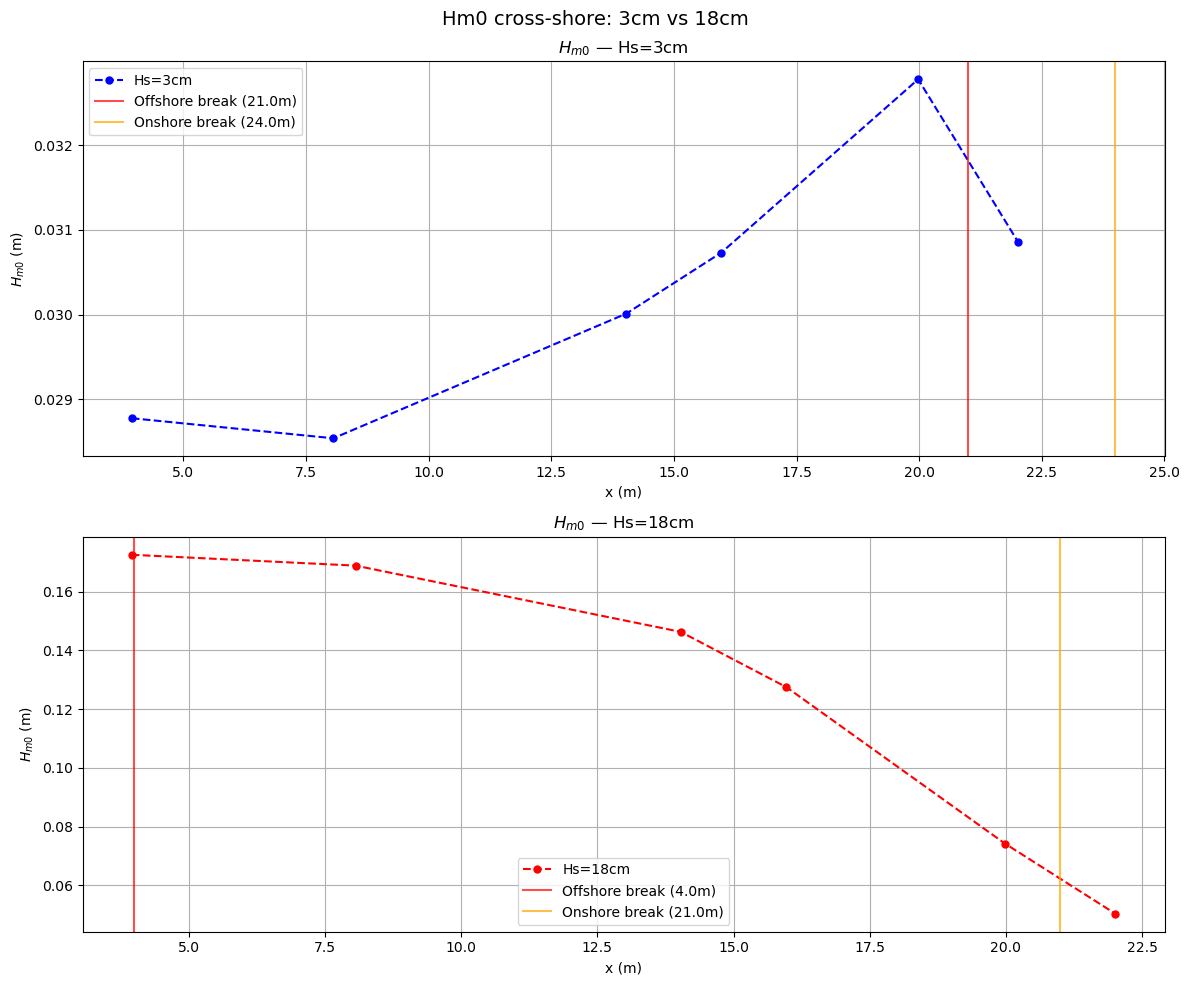

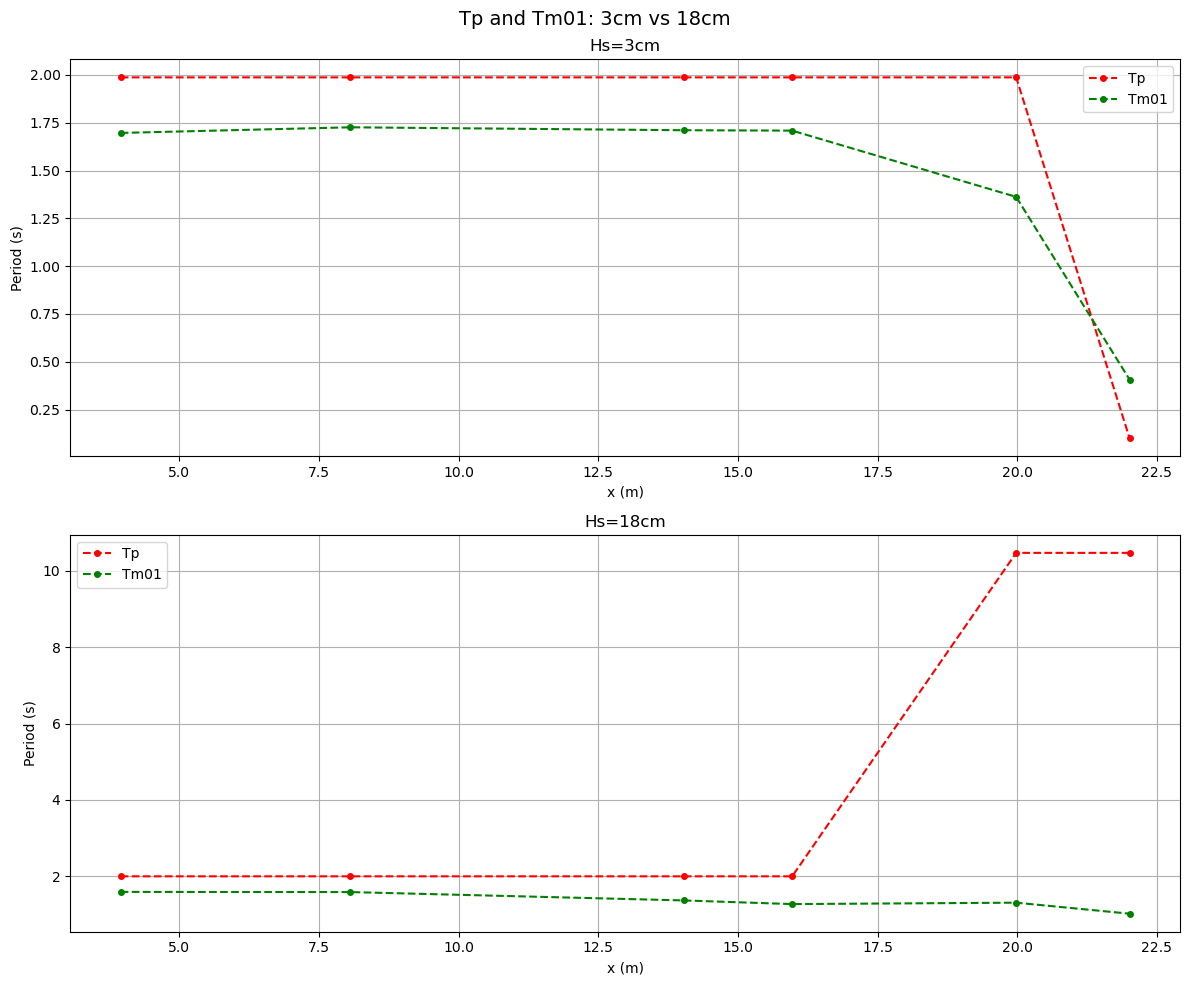

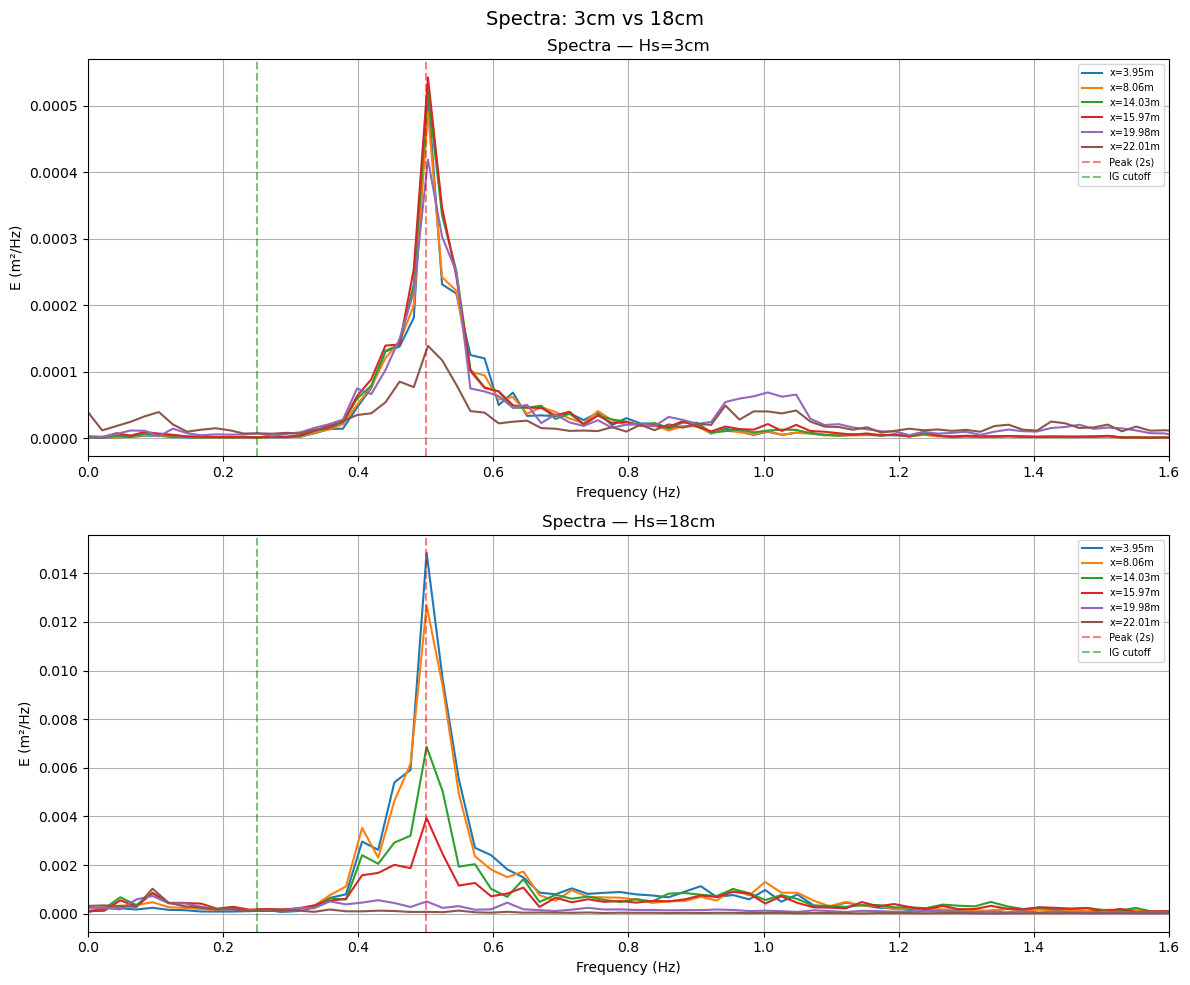

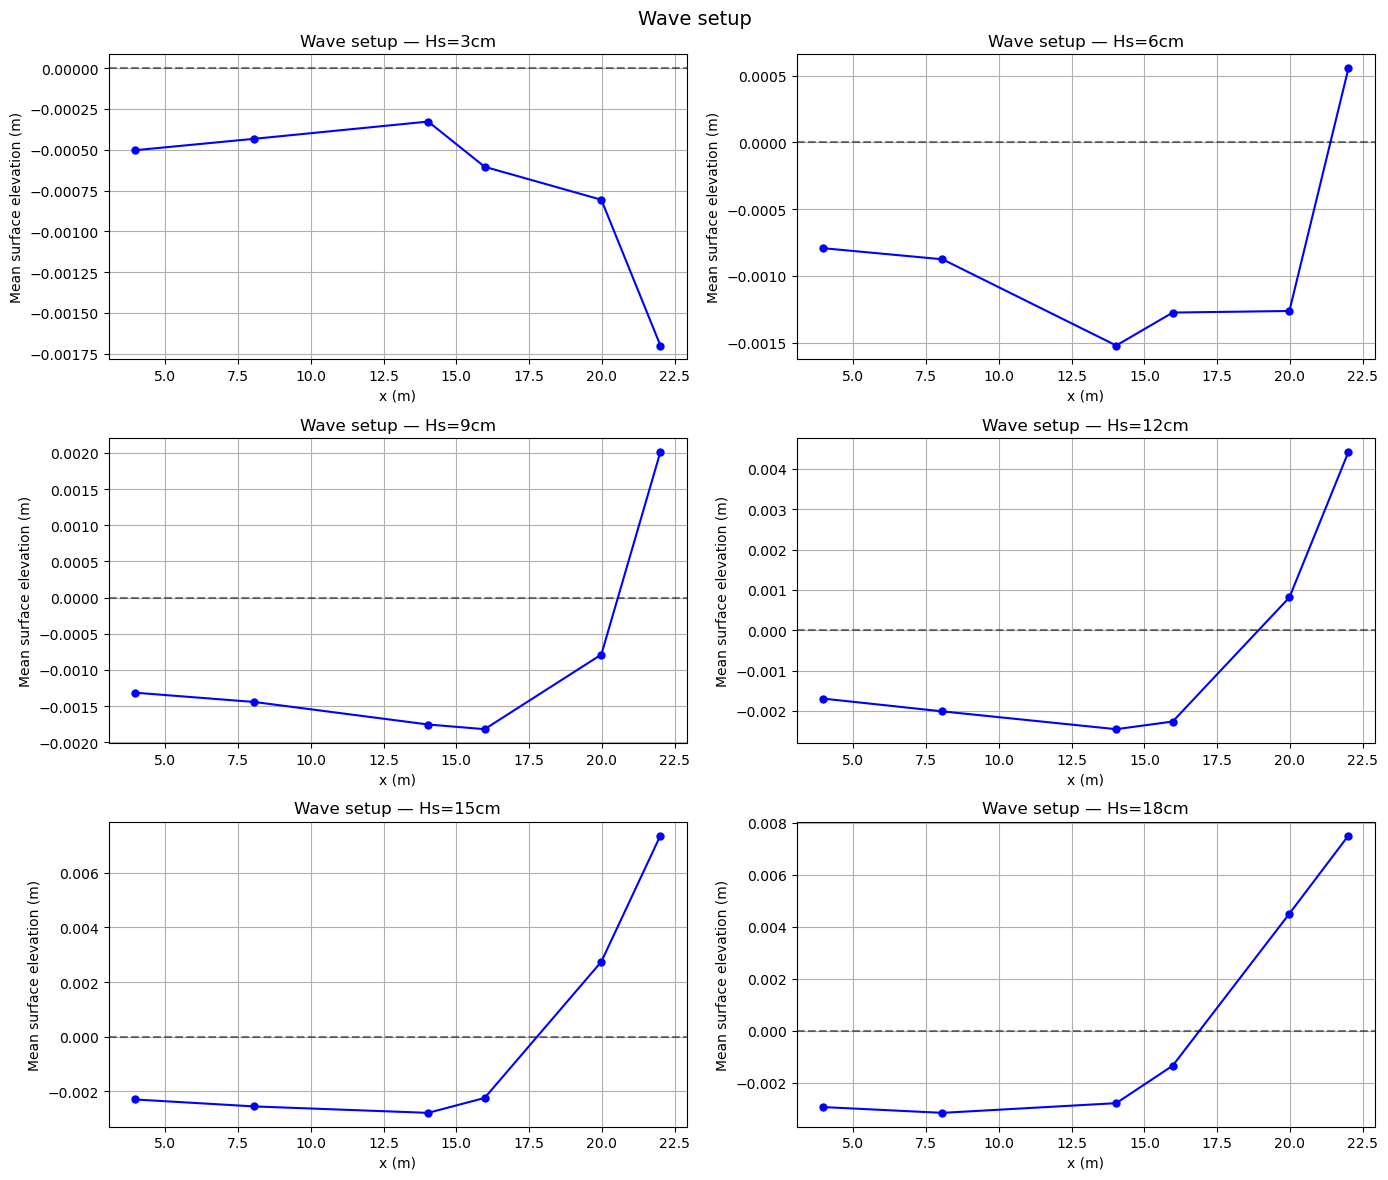

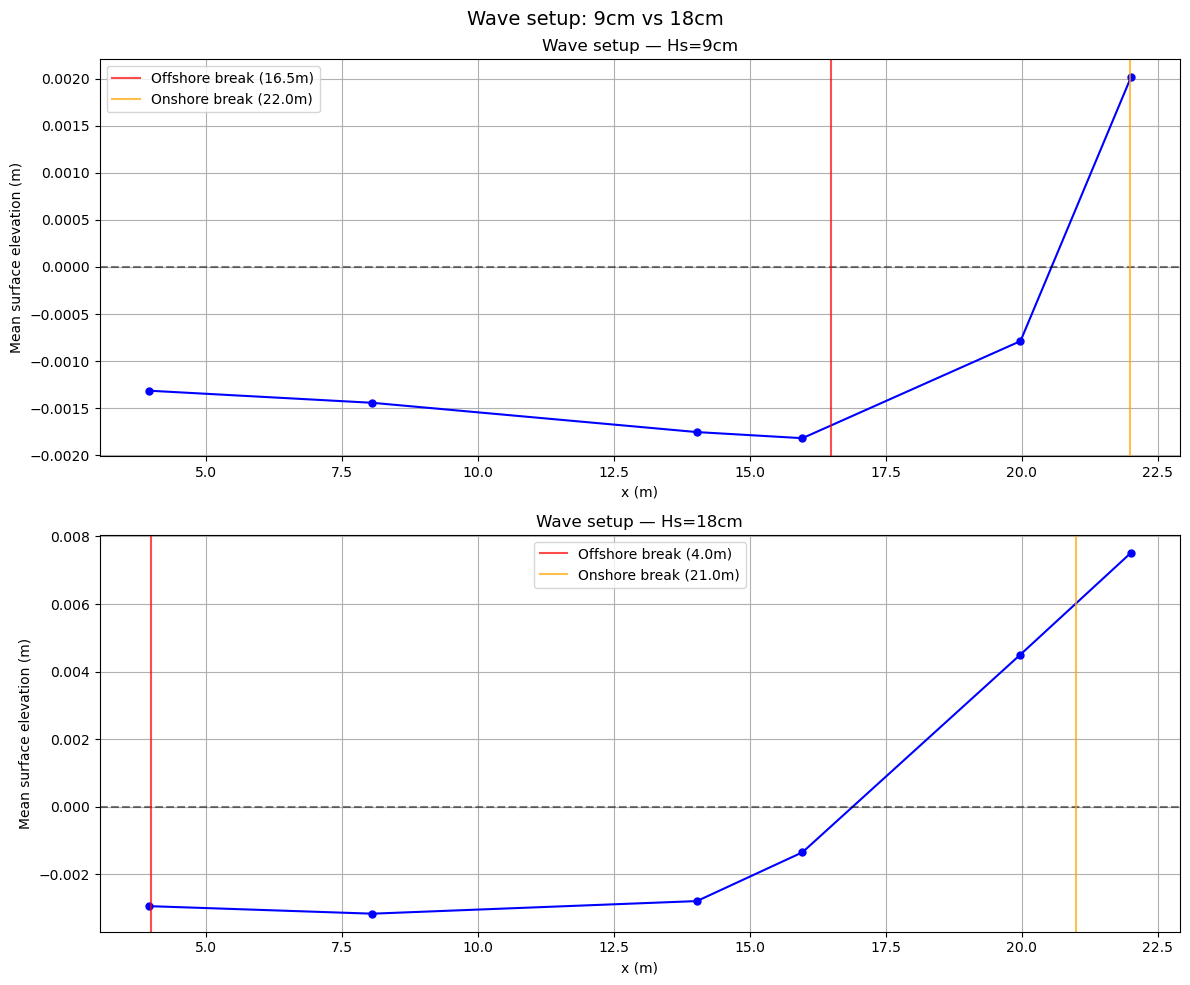

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

# ----------------------------------------------------------------
# Load data
# ----------------------------------------------------------------
def load_whm(filepath):
    raw  = np.genfromtxt(filepath, delimiter=";", skip_header=7)
    time = raw[:, 0]
    whms = [raw[:, i] for i in range(1, 7)]

    still = time < 60
    whms  = [w - np.mean(w[still]) for w in whms]

    mask  = (time >= 200) & (time <= time[-1] - 200)
    time  = time[mask]
    sens  = [0.0248, 0.0251, 0.0251, 0.0255, 0.0233, 0.0214]
    whms  = [w[mask] * s for w, s in zip(whms, sens)]
    return [time] + whms

cases     = [load_whm(f'Set{i}/WHM_test{i}.ASC') for i in range(1, 7)]
labels    = ['Hs=3cm', 'Hs=6cm', 'Hs=9cm', 'Hs=12cm', 'Hs=15cm', 'Hs=18cm']
positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]

# ----------------------------------------------------------------
# Core spectral function — returns f and E for one timeseries
# ----------------------------------------------------------------
def spectrum(data, Fs, nBlocks=15):
    nfft     = int(len(data) / nBlocks)
    nfft     = nfft - (nfft % 2)
    df       = Fs / nfft
    f        = np.arange(0, Fs/2 + df, df)
    blocks   = np.reshape(data[:nBlocks*nfft], (nBlocks, nfft))
    fft_data = 2 * fft(blocks, n=nfft, axis=1)[:, :len(f)] / nfft
    E        = np.mean(np.abs(fft_data)**2 / 2, axis=0) / df
    return f, E

def compute_stats(case, nBlocks=15):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    hm0, tp, tm01 = [], [], []
    for w in whms:
        f, E     = spectrum(w - np.mean(w), Fs, nBlocks)
        f1, E1   = f[1:], E[1:]
        m0       = np.trapz(E1, f1)
        m1       = np.trapz(E1 * f1, f1)
        hm0.append(4 * np.sqrt(m0))
        tp.append(1 / f1[np.argmax(E1)])
        tm01.append(m0 / m1)
    return hm0, tp, tm01

def plot_setup(time, WHM1, WHM2, WHM3, WHM4, WHM5, WHM6):
    whm_data      = [WHM1, WHM2, WHM3, WHM4, WHM5, WHM6]
    whm_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]
    setup = [np.mean(WHM) for WHM in whm_data]

    plt.figure(figsize=(8, 4))
    plt.plot(whm_positions, setup, color='blue', marker='o', markersize=6)
    plt.xlabel('x (m)', fontsize=12)
    plt.ylabel('Mean surface elevation (m)', fontsize=12)
    plt.title('Wave setup at WHM locations', fontsize=14)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.grid()
    plt.show()

# ----------------------------------------------------------------
# Plot 1: Hm0 cross-shore for all 6 cases
# ----------------------------------------------------------------
breakpoints = [(21.0,24.0),(18.2,23.0),(16.5,22.0),(13.0,22.0),(9.0,21.0),(4.0,21.0)]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, case, label, (x_off, x_on) in zip(axes.flatten(), cases, labels, breakpoints):
    hm0, _, _ = compute_stats(case)
    ax.plot(positions, hm0, linestyle='--', marker='o', markersize=6, color='blue')
    ax.axvline(x=x_off, color='red',    alpha=0.7, label=f'Offshore break ({x_off}m)')
    ax.axvline(x=x_on,  color='orange', alpha=0.7, label=f'Onshore break ({x_on}m)')
    ax.set(xlabel='x (m)', ylabel='$H_{m0}$ (m)', title=f'$H_{{m0}}$ — {label}')
    ax.legend(fontsize=8); ax.grid()
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# Plot 2: Spectra for all 6 cases
# ----------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for ax, case, label in zip(axes.flatten(), cases, labels):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    for w, pos in zip(whms, positions):
        f, E = spectrum(w - np.mean(w), Fs)
        ax.plot(f, E, label=f'x={pos}m')
    ax.axvline(x=0.5,  linestyle='--', color='red',   alpha=0.5, label='Peak (2s)')
    ax.axvline(x=0.25, linestyle='--', color='green', alpha=0.5, label='IG cutoff')
    ax.set(xlim=(0,2), xlabel='Frequency (Hz)', ylabel='E (m²/Hz)', title=f'Spectra — {label}')
    ax.legend(fontsize=7); ax.grid()
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# Plot 3: Tp and Tm01 for all 6 cases
# ----------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
for ax, case, label in zip(axes.flatten(), cases, labels):
    _, tp, tm01 = compute_stats(case)
    ax.plot(positions, tp,   color='red',   marker='o', linestyle='--', markersize=4, label='Tp')
    ax.plot(positions, tm01, color='green', marker='o', linestyle='--', markersize=4, label='Tm01')
    ax.set(xlabel='x (m)', ylabel='Period (s)', title=label)
    ax.grid()
axes.flatten()[0].legend()
plt.suptitle('Cross-shore evolution of Tp and Tm01', fontsize=14)
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# Plot 4: Hm0, Tp/Tm01, Spectra for 3cm vs 18cm (1 col, 2 rows each)
# ----------------------------------------------------------------
case_3cm  = cases[0]
case_18cm = cases[5]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label, color, (x_off, x_on) in zip(axes, [case_3cm, case_18cm], ['Hs=3cm', 'Hs=18cm'], ['blue', 'red'], [breakpoints[0], breakpoints[5]]):
    hm0, _, _ = compute_stats(case)
    ax.plot(positions, hm0, color=color, marker='o', linestyle='--', markersize=5, label=label)
    ax.axvline(x=x_off, color='red',    alpha=0.7, label=f'Offshore break ({x_off}m)')
    ax.axvline(x=x_on,  color='orange', alpha=0.7, label=f'Onshore break ({x_on}m)')
    ax.set(xlabel='x (m)', ylabel='$H_{m0}$ (m)', title=f'$H_{{m0}}$ — {label}')
    ax.legend(); ax.grid()
plt.suptitle('Hm0 cross-shore: 3cm vs 18cm', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label in zip(axes, [case_3cm, case_18cm], ['Hs=3cm', 'Hs=18cm']):
    _, tp, tm01 = compute_stats(case)
    ax.plot(positions, tp,   color='red',   marker='o', linestyle='--', markersize=4, label='Tp')
    ax.plot(positions, tm01, color='green', marker='o', linestyle='--', markersize=4, label='Tm01')
    ax.set(xlabel='x (m)', ylabel='Period (s)', title=label)
    ax.legend(); ax.grid()
plt.suptitle('Tp and Tm01: 3cm vs 18cm', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label in zip(axes, [case_3cm, case_18cm], ['Hs=3cm', 'Hs=18cm']):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    for w, pos in zip(whms, positions):
        f, E = spectrum(w - np.mean(w), Fs)
        ax.plot(f, E, label=f'x={pos}m')
    ax.axvline(x=0.5,  linestyle='--', color='red',   alpha=0.5, label='Peak (2s)')
    ax.axvline(x=0.25, linestyle='--', color='green', alpha=0.5, label='IG cutoff')
    ax.set(xlim=(0,1.6), xlabel='Frequency (Hz)', ylabel='E (m²/Hz)', title=f'Spectra — {label}')
    ax.legend(fontsize=7); ax.grid()
plt.suptitle('Spectra: 3cm vs 18cm', fontsize=14)
plt.tight_layout(); 
plt.show()

# --- All 6 subplots ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, case, label in zip(axes.flatten(), cases, labels):
    time, *whms = case
    ax.plot(positions, [np.mean(w) for w in whms], color='blue', marker='o', markersize=5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set(xlabel='x (m)', ylabel='Mean surface elevation (m)', title=f'Wave setup — {label}')
    ax.grid()
plt.suptitle('Wave setup', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label, (x_off, x_on) in zip(axes, [cases[2], cases[5]], ['Hs=9cm', 'Hs=18cm'], [breakpoints[2], breakpoints[5]]):
    _, *whms = case
    ax.plot(positions, [np.mean(w) for w in whms], color='blue', marker='o', markersize=5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(x=x_off, color='red',    alpha=0.7, label=f'Offshore break ({x_off}m)')
    ax.axvline(x=x_on,  color='orange', alpha=0.7, label=f'Onshore break ({x_on}m)')
    ax.set(xlabel='x (m)', ylabel='Mean surface elevation (m)', title=f'Wave setup — {label}')
    ax.legend(); ax.grid()
plt.suptitle('Wave setup: 9cm vs 18cm', fontsize=14)
plt.tight_layout(); plt.show()

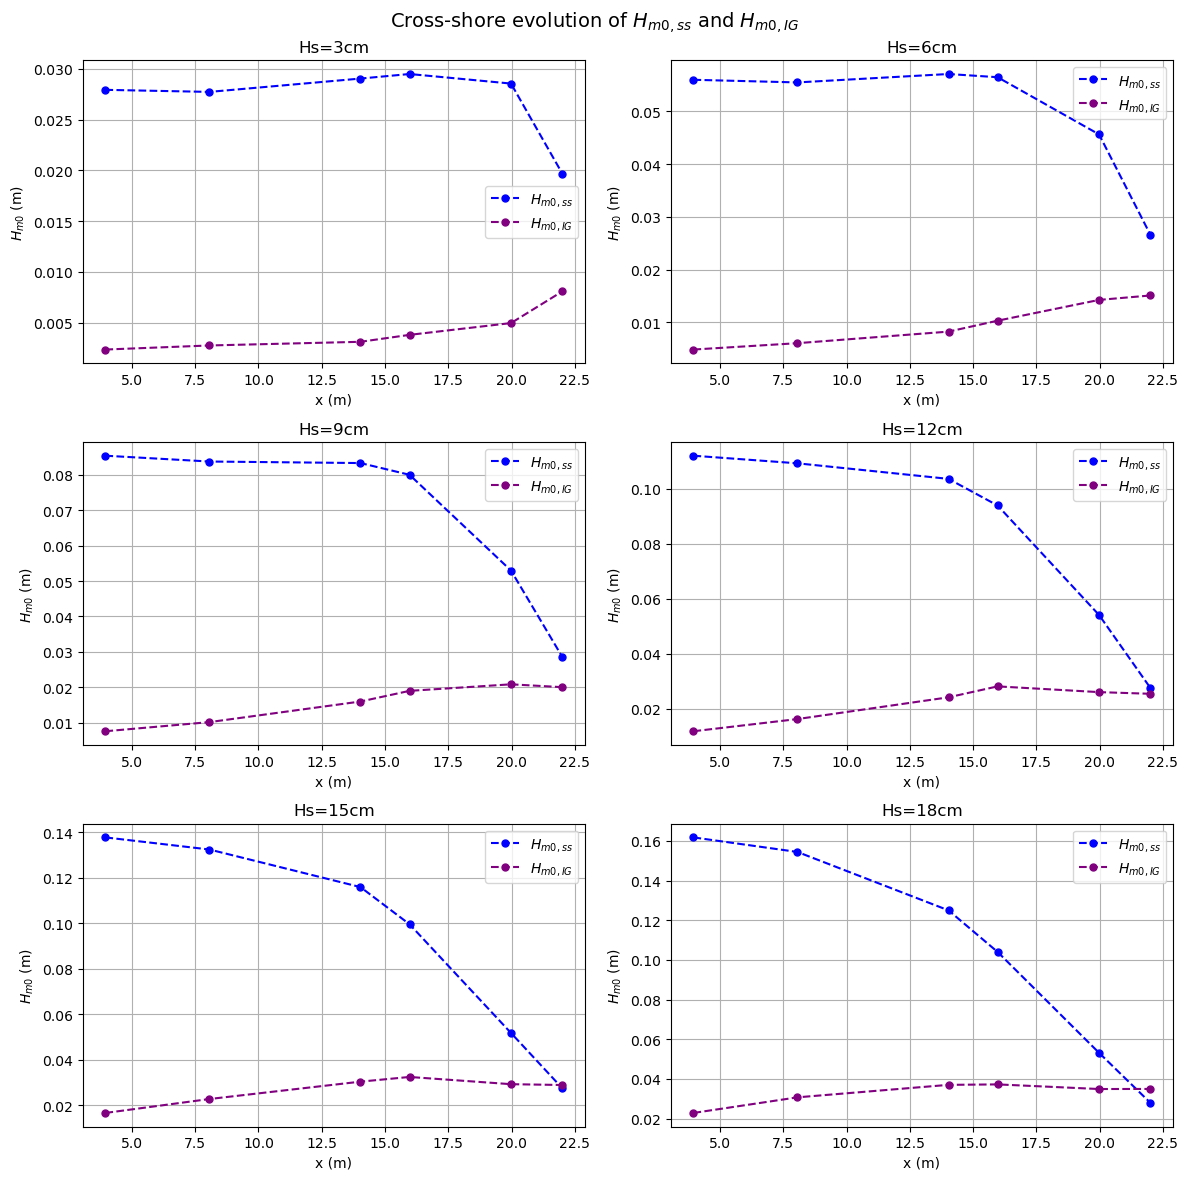

In [82]:
def compute_hm0_bands(case, nBlocks=15):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    hm0_ig, hm0_ss = [], []

    for w in whms:
        f, E = spectrum(w - np.mean(w), Fs, nBlocks)
        ig_mask = (f >= 0.005) & (f <= 0.25)
        ss_mask = (f >= 0.25)  & (f <= 1.0)
        hm0_ig.append(4 * np.sqrt(np.trapz(E[ig_mask], f[ig_mask])))
        hm0_ss.append(4 * np.sqrt(np.trapz(E[ss_mask], f[ss_mask])))

    return hm0_ig, hm0_ss

# --- All 6 cases ---
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, case, label in zip(axes.flatten(), cases, labels):
    hm0_ig, hm0_ss = compute_hm0_bands(case)
    ax.plot(positions, hm0_ss, color='blue',   marker='o', linestyle='--', markersize=5, label='$H_{m0,ss}$')
    ax.plot(positions, hm0_ig, color='purple', marker='o', linestyle='--', markersize=5, label='$H_{m0,IG}$')
    ax.set(xlabel='x (m)', ylabel='$H_{m0}$ (m)', title=f'{label}')
    ax.legend(); ax.grid()
plt.suptitle('Cross-shore evolution of $H_{m0,ss}$ and $H_{m0,IG}$', fontsize=14)
plt.tight_layout(); plt.show()


In [83]:
# Find depth at x = 22.01m
idx_22 = np.argmin(np.abs(x - 22.01))
h_22   = 0.51 - zbed[idx_22]
print(f"Water depth at x=22.01m: {h_22:.4f} m")

# Get WHM6 from cases
_, _, _, _, _, _, WHM6_03 = cases[0]  
_, _, _, _, _, _, WHM6_06 = cases[1] 
_, _, _, _, _, _, WHM6_09 = cases[2]
_, _, _, _, _, _, WHM6_12 = cases[3]
_, _, _, _, _, _, WHM6_15 = cases[4]
_, _, _, _, _, _, WHM6_18 = cases[5]  
print(h_22)
WHM6_03_demeaned = WHM6_03 - np.mean(WHM6_03)
WHM6_06_demeaned = WHM6_06 - np.mean(WHM6_06)
WHM6_09_demeaned = WHM6_09 - np.mean(WHM6_09)
WHM6_12_demeaned = WHM6_12 - np.mean(WHM6_12)
WHM6_15_demeaned = WHM6_15 - np.mean(WHM6_15)
WHM6_18_demeaned = WHM6_18 - np.mean(WHM6_18)
# Convert elevation to velocity using shallow water approximation
g          = 9.81
EMF6_03 = WHM6_03_demeaned * np.sqrt(g / h_22)  # or WHM6_06 for the 18cm case
EMF6_06 = WHM6_06_demeaned * np.sqrt(g / h_22)
EMF6_09 = WHM6_09_demeaned * np.sqrt(g / h_22)
EMF6_12 = WHM6_12_demeaned * np.sqrt(g / h_22)
EMF6_15 = WHM6_15_demeaned * np.sqrt(g / h_22)
EMF6_18 = WHM6_18_demeaned * np.sqrt(g / h_22)

def calculate_sediment_transport_new(time, EMF1, EMF2, EMF3, EMF4, EMF5, EMF6, Fs):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5, EMF6]

    u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total = [], [], [], [], []

    for EMF in emf_data:
        u_mean  = np.mean(EMF)
        u_dem   = EMF - u_mean
        u_ss    = frequency_filter(u_dem, Fs, f_low=0.25,  f_high=1.7)
        u_ig    = frequency_filter(u_dem, Fs, f_low=0.005, f_high=0.25)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    return emf_positions, u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total

emf_positions, u3_03, u3_ss_03, three_u2ss_u_03, three_u2ss_uig_03, sed_total_03 = calculate_sediment_transport_new(time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, EMF6_03, Fs=20)
emf_positions, u3_06, u3_ss_06, three_u2ss_u_06, three_u2ss_uig_06, sed_total_06 = calculate_sediment_transport_new(time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, EMF6_06, Fs=20)
emf_positions, u3_09, u3_ss_09, three_u2ss_u_09, three_u2ss_uig_09, sed_total_09 = calculate_sediment_transport_new(time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, EMF6_09, Fs=20)
emf_positions, u3_12, u3_ss_12, three_u2ss_u_12, three_u2ss_uig_12, sed_total_12 = calculate_sediment_transport_new(time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, EMF6_12, Fs=20)
emf_positions, u3_15, u3_ss_15, three_u2ss_u_15, three_u2ss_uig_15, sed_total_15 = calculate_sediment_transport_new(time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, EMF6_15, Fs=20)
emf_positions, u3_18, u3_ss_18, three_u2ss_u_18, three_u2ss_uig_18, sed_total_18 = calculate_sediment_transport_new(time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, EMF6_18, Fs=20)




Water depth at x=22.01m: 0.0815 m
0.081548134


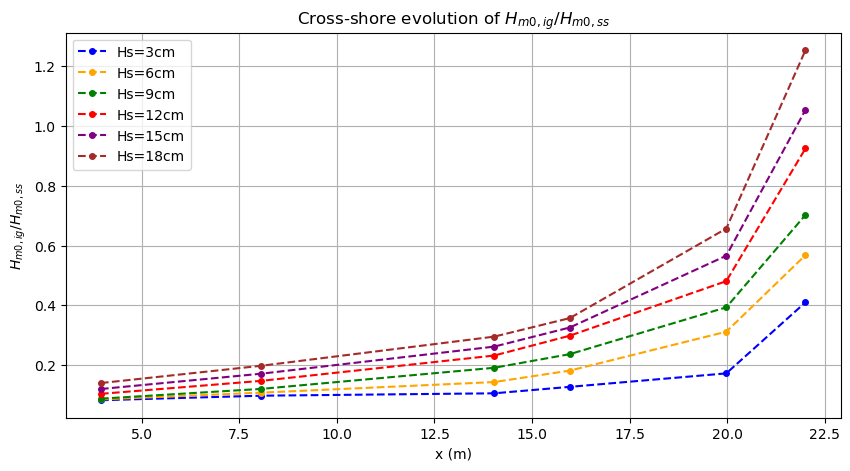

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for case, label, color in zip(cases, labels, colors):
    hm0_ig, hm0_ss = compute_hm0_bands(case)
    ratio = [ig/ss for ss, ig in zip(hm0_ss, hm0_ig)]
    ax.plot(positions, ratio, marker='o', linestyle='--', markersize=4, label=label, color=color)

ax.set_xlabel('x (m)')
ax.set_ylabel('$H_{m0,ig} / H_{m0,ss}$')
ax.set_title('Cross-shore evolution of $H_{m0,ig} / H_{m0,ss}$')
ax.legend()
ax.grid()
plt.show()

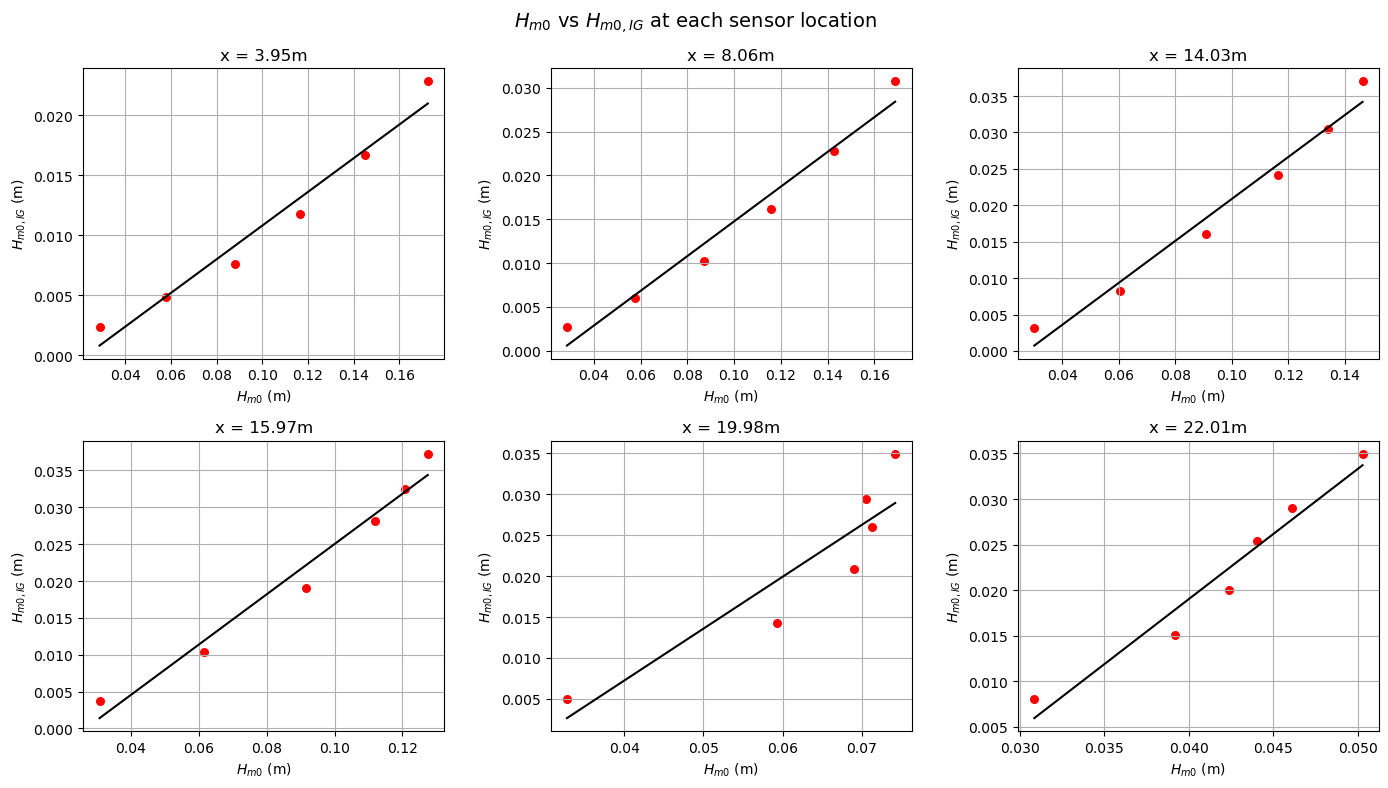

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, pos, i in zip(axes.flatten(), positions, range(6)):
    hs_vals  = []
    hig_vals = []
    for case, label in zip(cases, labels):
        hm0_ig, hm0_ss = compute_hm0_bands(case)
        hm0, _, _      = compute_stats(case)
        hs_vals.append(hm0[i])
        hig_vals.append(hm0_ig[i])

    # scatter plot
    ax.scatter(hs_vals, hig_vals, color='red', s=30)

    # linear fit
    m, b   = np.polyfit(hs_vals, hig_vals, 1)
    x_line = np.linspace(min(hs_vals), max(hs_vals), 100)
    ax.plot(x_line, m*x_line + b, color='black')

    ax.set_xlabel('$H_{m0}$ (m)')
    ax.set_ylabel('$H_{m0,IG}$ (m)')
    ax.set_title(f'x = {pos}m')
    ax.grid()

plt.suptitle('$H_{{m0}}$ vs $H_{{m0,IG}}$ at each sensor location', fontsize=14)
plt.tight_layout()
plt.show()

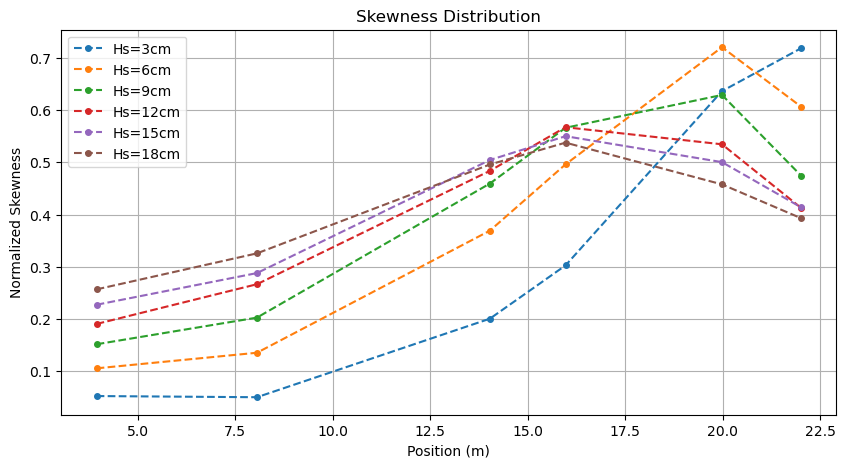

In [86]:
emf_cases = [
    (time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, EMF6_03),
    (time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, EMF6_06),
    (time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, EMF6_09),
    (time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, EMF6_12),
    (time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, EMF6_15),
    (time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, EMF6_18),
]
#calculate normalized skewness
def calculate_skewness(time, EMF, Fs):
    u_mean = np.mean(EMF)
    u_dem  = EMF - u_mean
    u_ss   = frequency_filter(u_dem, Fs, f_low=0.25, f_high=10)
    skewness_ss = np.mean((u_ss)**3) / np.mean((u_ss**2)**1.5)

    return skewness_ss

#plot normalized skewness for all cases
fig, ax = plt.subplots(figsize=(10, 5))
for case, label in zip(emf_cases, labels):
    time, *emfs = case
    skewness_values = [calculate_skewness(time, emf, Fs=20) for emf in emfs]
    ax.plot(positions, skewness_values, marker='o', linestyle='--', markersize=4, label=label)
ax.set_xlabel('Position (m)')
ax.set_ylabel('Normalized Skewness')
ax.set_title('Skewness Distribution')
ax.legend()
ax.grid()
plt.show()



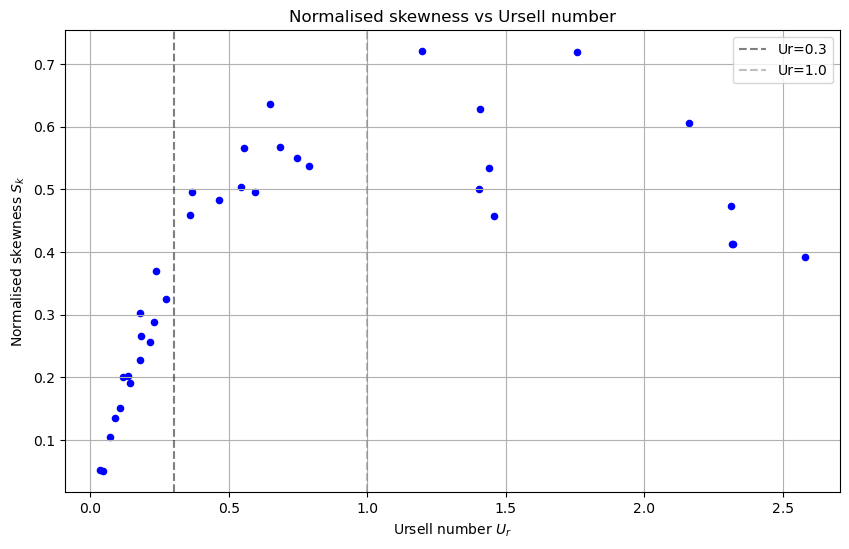

In [ ]:
#compute ursell number
from scipy.optimize import fsolve


def dispersion_relation(k,T, h):
    g = 9.81
    omega = 2 *np.pi / T
    return omega**2 - g * k * np.tanh(k * h)

def compute_ursell(Hs, T, h):
    g     = 9.81
    omega = 2 * np.pi / T
    # solve dispersion relation for k
    k0    = omega / np.sqrt(g * h)  # shallow water initial guess
    k     = fsolve(dispersion_relation, k0, args=(T, h))[0]    
    aw    = 0.5 * Hs
    Ur    = (3/4) * (aw * k) / (k * h)**3
    return Ur, k

water_levels = [0.510, 0.509, 0.508, 0.507, 0.506, 0.505]
Hs_values    = [0.03, 0.06, 0.09, 0.12, 0.15, 0.18]
T            = 2.0
sensor_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]
zbed_at_sensors  = [zbed[np.argmin(np.abs(x - pos))] for pos in sensor_positions]

emf_cases = [
    (time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, EMF6_03),
    (time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, EMF6_06),
    (time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, EMF6_09),
    (time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, EMF6_12),
    (time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, EMF6_15),
    (time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, EMF6_18),
]

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for emf_case, whm_case, wl, label, color in zip(emf_cases, cases, water_levels, labels, colors):
    time_emf, *emfs  = emf_case
    _, *whms         = whm_case
    setup_at_sensors = [np.mean(w) for w in whms]
    hm0_local, _, _  = compute_stats(whm_case)

    ur_vals, sk_vals = [], []

    for emf, pos, zb, setup, Hs_local in zip(emfs, sensor_positions, zbed_at_sensors, setup_at_sensors, hm0_local):
        h     = wl - zb + setup
        Ur, k = compute_ursell(Hs_local, T, h)
        sk    = calculate_skewness(time_emf, emf, Fs=20)
        ur_vals.append(Ur)
        sk_vals.append(sk)

    ax.scatter(ur_vals, sk_vals, color='blue', s=20)

ax.axvline(x=0.3, linestyle='--', color='black', alpha=0.5, label='Ur=0.3')
ax.axvline(x=1.0, linestyle='--', color='gray',  alpha=0.5, label='Ur=1.0')
ax.set_xlabel('Ursell number $U_r$')
ax.set_ylabel('Normalised skewness $S_k$')
ax.set_title('Normalised skewness vs Ursell number')
ax.legend()
ax.grid()
plt.show()

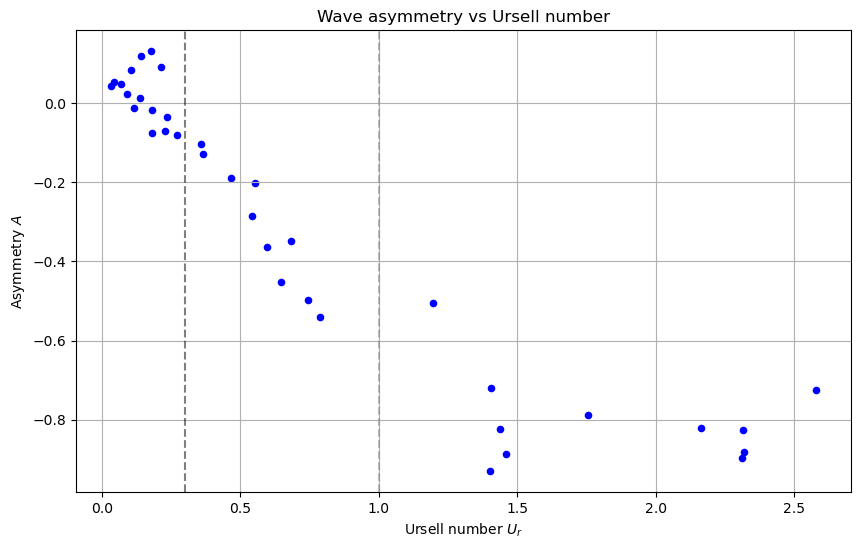

In [95]:
from scipy.signal import hilbert

def compute_wave_asymmetry(case):
    time, *whms = case
    As_vals = []
    for w in whms:
        w_dem = w - np.mean(w)
        w_hat = np.imag(hilbert(w_dem))
        sigma = np.std(w_dem)
        As_vals.append(np.mean(w_hat**3) / sigma**3)
    return As_vals

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for emf_case, whm_case, wl, label, color in zip(emf_cases, cases, water_levels, labels, colors):
    time_emf, *emfs  = emf_case
    _, *whms         = whm_case
    setup_at_sensors = [np.mean(w) for w in whms]
    hm0_local, _, _  = compute_stats(whm_case)
    As_list          = compute_wave_asymmetry(whm_case)

    ur_vals, As_vals = [], []

    for i, (emf, pos, zb, setup, Hs_local) in enumerate(zip(emfs, sensor_positions, zbed_at_sensors, setup_at_sensors, hm0_local)):
        h     = wl - zb + setup
        Ur, k = compute_ursell(Hs_local, T, h)
        ur_vals.append(Ur)
        As_vals.append(As_list[i])

    ax.scatter(ur_vals, As_vals, color="blue", s=20, label=label)

ax.axvline(x=0.3, linestyle='--', color='black', alpha=0.5, label='Ur=0.3')
ax.axvline(x=1.0, linestyle='--', color='gray',  alpha=0.5, label='Ur=1.0')
ax.set_xlabel('Ursell number $U_r$')
ax.set_ylabel('Asymmetry $A$')
ax.set_title('Wave asymmetry vs Ursell number')
ax.grid()
plt.show()

TEST: Seperate IG from SS waves

In [ ]:
def compute_ig_period(case, nBlocks=15):
    time, *whms = case
    T_ig_vals = []

    for w in whms:
        f, E    = spectrum(w - np.mean(w), Fs=20, nBlocks=nBlocks)
        ig_mask = (f >= 0.005) & (f <= 0.25)
        f_ig    = f[ig_mask]
        E_ig    = E[ig_mask]
        m0      = np.trapz(E_ig,         f_ig)
        m1      = np.trapz(E_ig * f_ig,  f_ig)
        T_ig_vals.append(m0 / m1)

    return T_ig_vals

#compute mean period of seaswell waves
def compute_seaswell_period(case, nBlocks=15):
    time, *whms = case
    Fs = 20
    T_sw_vals = []

    for w in whms:
        f, E    = spectrum(w - np.mean(w), Fs, nBlocks)
        ig_mask = (f >= 0.25) & (f <= 10)
        f_ig    = f[ig_mask]
        E_ig    = E[ig_mask]

        m0 = np.trapz(E_ig,       f_ig)
        m1 = np.trapz(E_ig * f_ig, f_ig)
        T_sw_vals.append(m0 / m1)   # Tm01 for IG band only

    return T_sw_vals

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for emf_case, whm_case, wl, label in zip(emf_cases, cases, water_levels, labels):
    time_emf, *emfs  = emf_case
    _, *whms         = whm_case
    setup_at_sensors = [np.mean(w) for w in whms]
    As_list          = compute_wave_asymmetry(whm_case)

    ur_vals, As_vals = [], []

    for i, (emf, pos, zb, setup, Hs_local, Hig_local) in enumerate(zip(emfs, sensor_positions, zbed_at_sensors, setup_at_sensors, hs_vals,hig_vals)):
        h     = wl - zb + setup
        Ur_ss, k = compute_ursell(Hs_local, T, h)
        ur_vals.append(Ur)
        As_vals.append(As_list[i])

    ax.scatter(ur_vals, As_vals, color="blue", s=20, label=label)

ax.axvline(x=0.3, linestyle='--', color='black', alpha=0.5, label='Ur=0.3')
ax.axvline(x=1.0, linestyle='--', color='gray',  alpha=0.5, label='Ur=1.0')
ax.set_xlabel('Ursell number $U_r$')
ax.set_ylabel('Asymmetry $A$')
ax.set_title('Wave asymmetry vs Ursell number')
ax.grid()
plt.show()